### This notebook is for doing an EDA of the Louisville Metro Animal Services (LMAS) intake and outcome data, which can be found here: https://data.louisvilleky.gov/datasets/733145c30ad94d43bdc6aba7fd0fdb09_0/explore. The date I pulled my data was 12/03/2025.

In [5]:
import pandas as pd

In [6]:
lmas_df = pd.read_csv('../data/animal_intake_data_2025.12.03.csv')

lmas_df.head()

,kennel,animalid,jurisdiction,intype,insubtype,indate,surreason,outtype,outsubtype,outdate,animaltype,sex,bites,petsize,color,breed,sourcezipcode,ObjectId
0,INTAKE,A430999,40204,OWNER SUR,EUTH REQ,2021-01-07 00:00:00,EUTH MED,EUTH,REQUESTED,2021-01-07 00:00:00,DOG,N,N,LARGE,WHITE / TAN,BASSET HOUND,40204,1
1,FOSTER,A423884,40211,STRAY,OTC,2025-03-07 00:00:00,STRAY,FOSTER,STRAY,2025-03-12 00:00:00,DOG,N,Y,SMALL,BLACK / TAN,MIN PINSCHER / MIN PINSCHER,40213,2
2,FOSTER,A423884,40213,FOSTER,RETURN,2025-04-13 00:00:00,FOSTER RET,ADOPTION,FOSTER,2025-04-13 00:00:00,DOG,N,Y,SMALL,BLACK / TAN,MIN PINSCHER / MIN PINSCHER,40213,3
3,N47,A583388,40228,OWNER SUR,OTC,2025-05-05 00:00:00,OWNER MED,ADOPTION,WALK IN,2025-05-20 00:00:00,CAT,N,N,X-LRG,ORANGE,DOMESTIC SH,40228,4
4,FREEZER,A558504,40215,STRAY,FIELD,2022-02-21 00:00:00,DOA,DISPOSAL,NECROPSY,2022-03-09 00:00:00,DOG,N,N,MED,BLUE,AMERICAN STAFF / MIX,40218,5


In [7]:
lmas_df.columns

Index(['kennel', 'animalid', 'jurisdiction', 'intype', 'insubtype', 'indate',
       'surreason', 'outtype', 'outsubtype', 'outdate', 'animaltype', 'sex',
       'bites', 'petsize', 'color', 'breed', 'sourcezipcode', 'ObjectId'],
      dtype='str')

In [8]:
lmas_df = lmas_df.drop('ObjectId', axis=1)

In [9]:
lmas_df.dtypes

kennel           str
animalid         str
jurisdiction     str
intype           str
insubtype        str
indate           str
surreason        str
outtype          str
outsubtype       str
outdate          str
animaltype       str
sex              str
bites            str
petsize          str
color            str
breed            str
sourcezipcode    str
dtype: object

In [10]:
lmas_df['indate'] = pd.to_datetime(lmas_df['indate'])
lmas_df['outdate'] = pd.to_datetime(lmas_df['outdate'])

In [11]:
lmas_df.dtypes

kennel                      str
animalid                    str
jurisdiction                str
intype                      str
insubtype                   str
indate           datetime64[us]
surreason                   str
outtype                     str
outsubtype                  str
outdate          datetime64[us]
animaltype                  str
sex                         str
bites                       str
petsize                     str
color                       str
breed                       str
sourcezipcode               str
dtype: object

In [12]:
duplicate_counts = lmas_df.apply(lambda x: x.duplicated(keep=False).sum())
print(duplicate_counts)

kennel           64658
animalid         23432
jurisdiction     64668
intype           64668
insubtype        64668
indate           64668
surreason        64666
outtype          64668
outsubtype       64659
outdate          64661
animaltype       64668
sex              64668
bites            64668
petsize          64668
color            64550
breed            64262
sourcezipcode    64421
dtype: int64


In [13]:
lmas_df[lmas_df.duplicated(['animalid'], keep=False)]

,kennel,animalid,jurisdiction,intype,insubtype,indate,surreason,outtype,outsubtype,outdate,animaltype,sex,bites,petsize,color,breed,sourcezipcode
1,FOSTER,A423884,40211,STRAY,OTC,2025-03-07,STRAY,FOSTER,STRAY,2025-03-12,DOG,N,Y,SMALL,BLACK / TAN,MIN PINSCHER / MIN PINSCHER,40213
2,FOSTER,A423884,40213,FOSTER,RETURN,2025-04-13,FOSTER RET,ADOPTION,FOSTER,2025-04-13,DOG,N,Y,SMALL,BLACK / TAN,MIN PINSCHER / MIN PINSCHER,40213
10,N16,A688292,40218,STRAY,FIELD,2021-01-19,STRAY,FOSTER,NaN,2021-03-21,DOG,S,N,MED,BROWN / WHITE,PIT BULL,40218
20,308,A688944,40214,STRAY,OTC,2021-02-05,STRAY,RTO,IN KENNEL,2021-02-09,DOG,S,N,LARGE,TAN / WHITE,GERM SHEPHERD / LABRADOR RETR,40214
21,N34,A689013,40212,STRAY,FIELD,2021-05-28,ABANDON,ADOPTION,INTERNET,2021-06-22,DOG,S,N,MED,GRAY,PIT BULL,40218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64651,FOSTER,A782748,40218,STRAY,OTC,2025-06-17,STRAY,FOSTER,STRAY,2025-06-22,DOG,S,N,SMALL,BRN MERLE,DACHSHUND,40291
64652,FOSTER,A782748,40218,FOSTER,RETURN,2025-08-01,STRAY,FOSTER,VACATION,2025-08-01,DOG,S,N,SMALL,BRN MERLE,DACHSHUND,40222
64653,FOSTER,A782748,40218,FOSTER,RETURN,2025-08-07,STRAY,TRANSFER,RESCUE GRP,2025-08-09,DOG,S,N,SMALL,BRN MERLE,DACHSHUND,40258
64655,N06,A768118,40299,FOSTER,RETURN,2024-11-09,FOSTER RET,ADOPTION,FACEBOOK,2024-11-09,DOG,S,N,MED,BR BRINDLE,PIT BULL,40211


As stated in my previous project, the animal ID appears to be duplicated when an animal is returned or found after adoption, so I don't want to discard the duplicates.

In [14]:
lmas_df.isnull().sum()

kennel               0
animalid             0
jurisdiction     13450
intype               0
insubtype          182
indate               0
surreason        13450
outtype          13790
outsubtype       23311
outdate          13755
animaltype           0
sex               1039
bites            13434
petsize           2453
color                1
breed               77
sourcezipcode     9591
dtype: int64

Animal id is never null, nor is intype, indate, or animal type, so I don't think I want to discard any nulls. I will go ahead and fill them in with the following values:

jurisdiction: unknown

insubtype: none

surreason: unknown

outtype: unknown

outsubtype: none

outdate: pd.NaT

sex: unknown

bites: unknown

petsize: unknown

color: unknown

breed: unknown

sourcezipcode: unknown

In [16]:
lmas_df['jurisdiction'].fillna("unknown")
lmas_df['insubtype'].fillna('none')
lmas_df['surreason'].fillna('unknown')
lmas_df['outtype'].fillna('unknown')
lmas_df['outsubtype'].fillna('none')
lmas_df['outdate'].fillna(pd.NaT)
lmas_df['sex'].fillna('unknown')
lmas_df['bites'].fillna('unknown')
lmas_df['petsize'].fillna('unknown')
lmas_df['color'].fillna('unknown')
lmas_df['breed'].fillna('unknown')
lmas_df['sourcezipcode'].fillna('unknown')

0          40204
1          40213
2          40213
3          40228
4          40218
          ...   
64663    unknown
64664      40219
64665      40229
64666      40214
64667      40205
Name: sourcezipcode, Length: 64668, dtype: str

In [18]:
lmas_df.rename(columns={
    'animalid': 'animal_id',
    'intype': 'intake_type',
    'insubtype': 'intake_subtype',
    'indate': "intake_date",
    'surreason': 'surrender_reason',
    'outtype': 'out_type',
    'outsubtype': 'out_subtype',
    'outdate': 'out_date',
    'animaltype': "animal_type",
    'petsize': 'size',
    'sourcezipcode': "source_zip_code"
}, inplace=True)

lmas_df.head()

,kennel,animal_id,jurisdiction,intake_type,intake_subtype,intake_date,surrender_reason,out_type,out_subtype,out_date,animal_type,sex,bites,size,color,breed,source_zip_code
0,INTAKE,A430999,40204,OWNER SUR,EUTH REQ,2021-01-07,EUTH MED,EUTH,REQUESTED,2021-01-07,DOG,N,N,LARGE,WHITE / TAN,BASSET HOUND,40204
1,FOSTER,A423884,40211,STRAY,OTC,2025-03-07,STRAY,FOSTER,STRAY,2025-03-12,DOG,N,Y,SMALL,BLACK / TAN,MIN PINSCHER / MIN PINSCHER,40213
2,FOSTER,A423884,40213,FOSTER,RETURN,2025-04-13,FOSTER RET,ADOPTION,FOSTER,2025-04-13,DOG,N,Y,SMALL,BLACK / TAN,MIN PINSCHER / MIN PINSCHER,40213
3,N47,A583388,40228,OWNER SUR,OTC,2025-05-05,OWNER MED,ADOPTION,WALK IN,2025-05-20,CAT,N,N,X-LRG,ORANGE,DOMESTIC SH,40228
4,FREEZER,A558504,40215,STRAY,FIELD,2022-02-21,DOA,DISPOSAL,NECROPSY,2022-03-09,DOG,N,N,MED,BLUE,AMERICAN STAFF / MIX,40218


#### Grouping and aggregating data after basic clean-up:

In [20]:
animal_type_count = lmas_df['animal_type'].value_counts()
animal_type_count

animal_type
DOG           33652
CAT           30051
RABBIT          358
OTHER           335
BIRD            182
LIVESTOCK        62
GUINEA PIG       28
Name: count, dtype: int64

In [21]:
import matplotlib.pyplot as plt

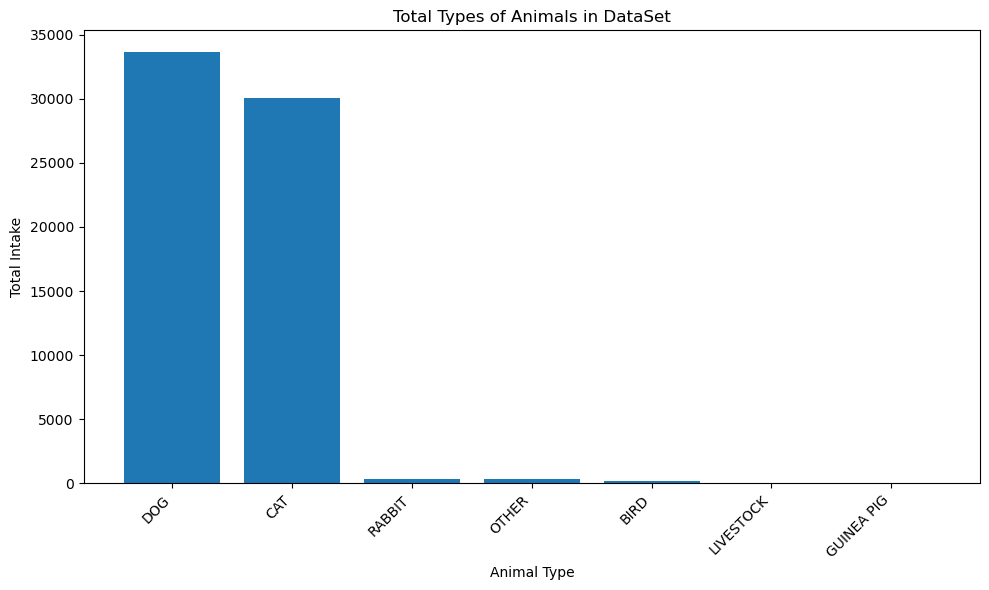

In [22]:
plt.figure(figsize=(10, 6))

color = "#2702AD"

plt.bar(animal_type_count.index, animal_type_count.values)

plt.xlabel('Animal Type')
plt.ylabel("Total Intake")
plt.title("Total Types of Animals in DataSet")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()